<div style="
    display: flex;
    justify-content: center;
    align-items: center;
    flex-direction: column;
    max-width: 99%;
    box-sizing: border-box;
    border: 1px solid rgba(208, 49, 30, 0.25);
    border-radius: 20px 20px 5px 5px;
    padding: 30px 40px;
    margin: 20px 0 30px 0;
    text-align: center;
    background: linear-gradient(135deg, rgba(208, 49, 30, 0.08), rgba(208, 49, 30, 0.02));
    box-shadow: 0 2px 15px rgba(208, 49, 30, 0.08);
    backdrop-filter: blur(3px);
    font-family: 'Palatino', serif;
">
    <div style="
        display: inline-block;
        background: #FF5722;
        color: #ffffff;
        padding: 4px 5px;
        border-radius: 30px;
        font-size: 11px;
        font-weight: 600;
        letter-spacing: 5px;
        box-shadow: 0 2px 8px rgba(208, 49, 30, 0.3);
        margin-bottom: 15px;
    ">
        SCHOOL 21
    </div>
    <h1 style="
        margin: 0;
        color: #F7D87F;
        font-size: clamp(24px, 4vw, 32px);
        font-weight: 700;
        letter-spacing: 1px;
        word-wrap: break-word;
    ">
        ML2_Supervised_learning
    </h1>
    <div style="
        display: flex;
        justify-content: center;
        gap: 10px;
        margin-top: 10px;
        flex-wrap: wrap;
    ">
        <span style="width: 30px; height: 2px; background: #D0311E; opacity: 0.25; flex-shrink: 0;"></span>
        <span style="width: 60px; height: 2px; background: #D0311E; opacity: 0.5; flex-shrink: 0;"></span>
        <span style="width: 30px; height: 2px; background: #D0311E; opacity: 0.25; flex-shrink: 0;"></span>
    </div>
    <p style="
        margin: 8px 0 0 0;
        color: #F8EBAB;
        font-size: 14px;
        font-style: italic;
        letter-spacing: 1px;
        word-wrap: break-word;
    ">
        joanegla
    </p>
</div>

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 01
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Import & define helper functions
    </h2>
</div>

In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.linear_model import LinearRegression, SGDRegressor 
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as rmse, mean_squared_error as mse, r2_score as r2


In [2]:
def display_table(df, title, hide_index=False):
    from IPython.display import display, HTML

    styler = df.style.set_table_styles([
        {'selector': 'th', 'props': [('background', "#FF5722"), ('color', 'white'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [('background', "#F7D87F")]},
        {'selector': 'tbody tr:nth-child(odd)', 'props': [('background', "#F8EBAB")]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px'), ('color', '#5E244E')]},
    ])
    
    if hide_index:
        styler = styler.hide(axis='index')
    
    html_table = styler.to_html()
    
    full_html = f"""
    <div style="text-align: center; margin: 20px 0;">
        <h3 style="text-align: center;">{title}</h3>
        <div style="display: inline-block; margin: 0 auto;">
            {html_table}
        </div>
    </div>
    """
    display(HTML(full_html))

In [3]:
def concatenate(result, model, type, train_pred, test_pred, y_train, y_val):
    """Добавление метрик моделей в таблицу"""

    if type == 'mae':
        train_metric = mae(y_train, train_pred)
        test_metric = mae(y_val, test_pred)
    elif type == 'rmse':
        train_metric = np.sqrt(mse(y_train, train_pred))
        test_metric = np.sqrt(mse(y_val, test_pred))
    elif type == 'r2':
        train_metric = R2_score(y_train, train_pred)
        test_metric = R2_score(y_val, test_pred)
    
    result = pd.concat([
        result,
        pd.DataFrame({
            'model': [model],
            'train': [train_metric],
            'test': [test_metric],
            'variance': [train_metric - test_metric]
            })
        ], ignore_index=True)
    return result

In [4]:
def processing_model(model, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val, type_normolization = None):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_val)

    if type_normolization: suffix = f'_{type_normolization}'
    else: suffix = ''

    tableMAE = concatenate(tableMAE, model.__class__.__name__ + suffix, 'mae', train_pred, test_pred, y_train, y_val)
    tableRMSE = concatenate(tableRMSE, model.__class__.__name__ + suffix, 'rmse', train_pred, test_pred, y_train, y_val)
    tableR2 = concatenate(tableR2, model.__class__.__name__ + suffix, 'r2', train_pred, test_pred, y_train, y_val)

    return tableMAE, tableRMSE, tableR2

In [5]:
def scaler_processing(model, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val, type_normolization = 'MinMaxScaler'):
    if type_normolization == 'StandardScaler': scaler = StandardScaler()
    else: scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train.copy())
    X_val_scaled = scaler.transform(X_val.copy())

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_val_scaled)

    tableMAE = concatenate(tableMAE, model.__class__.__name__ + f'_{type_normolization}', 'mae', train_pred, test_pred, y_train, y_val)
    tableRMSE = concatenate(tableRMSE, model.__class__.__name__ + type_normolization, 'rmse', train_pred, test_pred, y_train, y_val)
    tableR2 = concatenate(tableR2, model.__class__.__name__ + type_normolization, 'r2', train_pred, test_pred, y_train, y_val)

    return tableMAE, tableRMSE, tableR2

In [6]:
def remove_punctuation(df):
    """
    Функция для удаления некоторой пунктуации из признаков
    """
    df['features'] = df['features'].astype(str).str.translate(str.maketrans('', '', '[]"\' '))
    return df

In [7]:
def get_features(df):
    """
    Функция для выделения отдельных характеристик из столбца features
    """
    features = []
    for i, row in df.iterrows():
        if isinstance(row['features'], str):
            slice = row['features'].split(',')
            for i in slice:
                if i != '': features.append(i.strip())
        else:
            if row['features'] != '' and row['features'] is not None:
                features.append(row['features'])
    return features

In [8]:
def feature_engineering(df, features):
    """
    Функция выделяет 20 самых популярных признаков и добавляет их в датафрейм
    """
    top = Counter(features).most_common(20)
    top20 = [item for item, c in top]
    for feature in top20:
        df[feature] = df['features'].apply(lambda x: 1 if feature in x else 0)

    feature_list = top20 + ['bathrooms', 'bedrooms']
    return feature_list

In [9]:
def take_time(model, X):
    start = time.time()
    model.fit_transform(X)
    self_time = time.time() - start
    return self_time

def compare_normalization(result, model):
    return pd.concat([
        result,
        pd.DataFrame({
            "model": [model.__class__.__name__],
            "Скорость": [take_time(model, X_train)]
        })
    ])

In [10]:
from IPython.display import display, HTML
display(HTML("""
    <style>
        img {
            display: block;
            margin-left: auto;
            margin-right: auto;
        }
    </style>
    """))

In [11]:
def get_graph(data, name):
    plt.figure(figsize=(12, 6))
    sns.barplot(data=data.sort_values('test'), x='model', y='test', color='#FF5722')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Сравнение {name} моделей')
    plt.tight_layout()
    plt.show()

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 02
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Introduction
    </h2>
</div>

#### $\color{red}※$ Аналитическое решение задачи регрессии
Пусть дана матрица признаков $X = (x_{ij} \in \R \mid i = \overline{1,n}, j = \overline{1,k})$ и вектор целевой переменной $y = (y_j \in R \mid j = \overline{1,k})$ 

Тогда вектор весов модели $w$ высчитывается по формуле:
$$w = \color{red}(X^TX) ^{-1} X^Ty$$

При этом для учёта свободного члена, который отвечает за смещение, к матрице $X$ добавляется столбец из единиц: $X = [1 ∣ X]$

Замечание:

Данная формула имеет рещение, если матрица $X^TX$ невыроженная (отсутствие мультиколлинеарности), тогда она обратима

<details>
<summary>Вывод формулы</summary>

Модель можно выразить следующей матричной формулой:

$y = X\theta$

где
$X$ - матрица признаков размером N строк на D+1 столбцов (N - количество объектов, а D - количество признаков + 1 столбец свободных членов для смещения)
$\theta$ - вектор-столбец весов

Чтобы найти оптимальное решение, воспользуемся функицей потерь ( в частости MSE, как дифференцируемой и имеющей аналитическое решение функцией )
$J(\theta) = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y_i})^2$

Представим в матричной форме:
$J(\theta) = \frac{1}{N}\sum_{i=1}^{N}(y_i - x_i^T\theta)^2$

$$X\theta = \begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1D} \\
x_{21} & x_{22} & \cdots & x_{2D} \\
\vdots & \vdots & \ddots & \vdots \\
x_{N1} & x_{N2} & \cdots & x_{ND}
\end{pmatrix}
\begin{pmatrix}
\theta_1 \\
\theta_2 \\
\vdots \\
\theta_D
\end{pmatrix}
=
\begin{pmatrix}
x_1^T\theta \\
x_2^T\theta \\
\vdots \\
x_N^T\theta
\end{pmatrix}$$

$$e = y - X\theta = \begin{pmatrix}
y_1 - x_1^T\theta \\
y_2 - x_2^T\theta \\
\vdots \\
y_N - x_N^T\theta
\end{pmatrix}
=
\begin{pmatrix}
e_1 \\
e_2 \\
\vdots \\
e_N
\end{pmatrix}$$

Сумму квадратов ошибок можно предсавить скалярным произвееднием вектора ошибок на самого себя:
$J(\theta) = (y_i - x_i^T\theta)^T(y_i - x_i^T\theta)$

$$e^T e = \begin{pmatrix}
e_1 & e_2 & \cdots & e_N
\end{pmatrix}
\begin{pmatrix}
e_1 \\
e_2 \\
\vdots \\
e_N
\end{pmatrix}
= e_1^2 + e_2^2 + \cdots + e_N^2 = \sum_{i=1}^{N} e_i^2$$


Продифференцируем функцию:

$\frac{d}{d\theta}(y_i - x_i^T\theta)^T(y_i - x_i^T\theta) = -2X^Ty + 2X^TX\theta$

Приравняем полученный градиент к 0:

$-2X^Ty + 2X^TX\theta = 0$

$X^TX\theta = X^Ty$

$\color{red}\theta=(X^TX)^{-1}(X^Ty)$

</details>

---

#### $\color{red}※$ L1 & L2 регуляризация и изменение решения
Базовая формула функции потерь, в частности Mean Squeared Error (MSE), выражается следующим образом: 
$$\color{red}\frac{1}{n}\sum^n_{i=1}(y_i - \hat{y_i})^2$$
где:

$n$ - количество наблюдений
$y_i$ - фактические значения
$\hat{y_i}$ - значения, предсказанные моделью

##### Добавление L1 регуляризации
добавляет в эту функцию штраф в виде суммы абсолютных значений весов, умноженную на $\alpha$ (величину штрафа):
$$MSE = \frac{1}{n}\sum^n_{i=1}(y_i - \hat{y_i})^2 \color{red} + \alpha \sum^k_{j=1}|\theta_j|$$
**НО**
Данная добавляемая величина не дифференцируема в нуле, а значит получить простое аналитическое решение невозможно.

Для решения L1 используются численные методы, например, координатный спуск, через субградиент
##### Добавление L2 регуляризации
добавляет сумму квадратов весов, умноженную на величину штрафа
$$MSE = \frac{1}{n}\sum^n_{i=1}(y_i - \hat{y_i})^2 \color{red} + \alpha \sum^k_{j=1}\theta_j^2$$
Перепишем в матричной форме
$$(y_i - x_i^T\theta)^T(y_i - x_i^T\theta) + \alpha\theta^T\theta$$
Продифференцируем и приравняем к нулю
$$-2X^Ty + 2X^TX\theta + 2\alpha\theta = 0$$
Выносим $\theta$ за скобку. ($I$ - единичная матрица для обратимости)
$$(X^TX + \alpha I)\theta = X^Ty$$

$$\theta = \color{red}(X^TX + \alpha I)^{-1}X^Ty$$



L1 добавляет в аналитическую функцию штраф:

$(y_i - x_i^T\theta)^T(y_i - x_i^T\theta) + \alpha \sum^k_{j=1}|\theta_j|$

#### $\color{red}※$ Обнуление весов L1 регуляризацией
L2-норма: Область ограничений представляет собой гиперсферу — гладкое тело без углов. Градиент нормы определен и непрерывен во всех точках поверхности, кроме начала координат. Точка касания контуров функции потерь и сферы почти никогда не лежит на осях координат. Решение является проекцией оценки наименьших квадратовна сферу: оно сжимает все компоненты вектора пропорционально, но сохраняет их ненулевыми.

L1-норма: Область ограничений представляет собой октаэдр. Это полиэдр, обладающий острыми вершинами и ребрами, лежащими на подпространствах меньшей размерности, осях координат. Вероятность того, что контур функции потерь коснется политопа именно в его вершине или на ребре, экспоненциально возрастает с ростом размерности 𝑑. В точке минимума одна или несколько компонент вектора обращаются в ноль.
#### $\color{red}※$ Нелинейные зависимости
Вручную создаются новые признаки путем возведения существующих в степень или их комбинаций. Например, если у нас есть признак $𝑥$, мы можем подать в линейную регрессию вектор [1,$x$,$x^2$,$x^3$,...]. Линейная комбинация этих новых признаков даст полиномиальную зависимость относительно исходного $x$:
$$y = w_0 + w_1x + w_2x^2 + w_3x^3 + ...$$

Модель остается линейной по весам $𝑤$, но график предсказаний будет параболой или кубической кривой.

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 03
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Processing
    </h2>
</div>

In [12]:
train_data = pd.read_json('data/train.json')
test_data = pd.read_json('data/test.json')

<Axes: xlabel='price', ylabel='Count'>

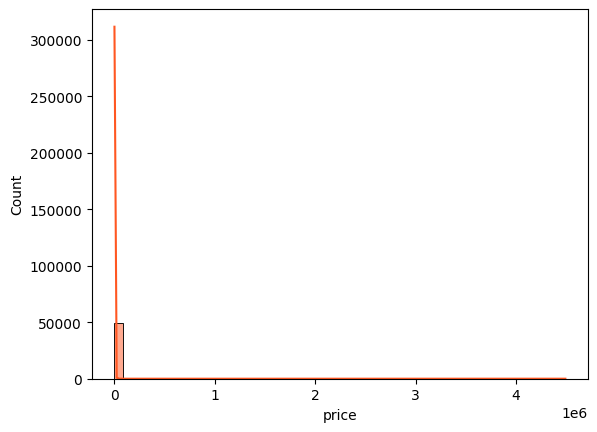

In [13]:
sns.histplot(data=train_data, x='price', bins=50, kde=True, color='#FF5722')

In [14]:
train = train_data[(train_data['price'] < train_data['price'].quantile(0.99)) & (train_data['price'] > train_data['price'].quantile(0.01))].copy()

<Axes: xlabel='price', ylabel='Count'>

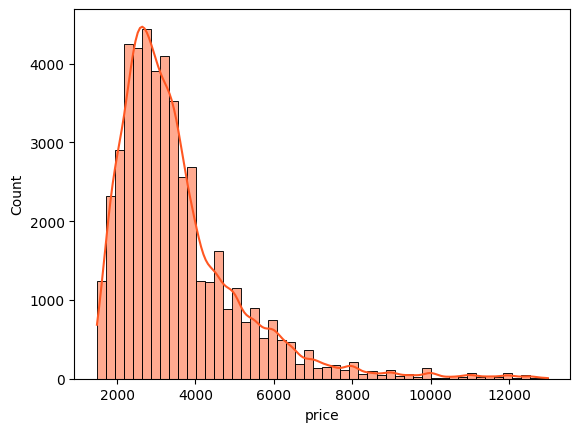

In [15]:
sns.histplot(data=train, x='price', bins=50, kde=True, color='#FF5722')

In [16]:
def processing_data(train_data, test_data):
    train_data = remove_punctuation(train_data)
    test_data = remove_punctuation(test_data)

    features_test = get_features(train_data)
    features_train = get_features(test_data)

    print(f'Всего значений train: {len(features_train)}')
    print(f'Уникальных значений train: {len(set(features_train))}')
    print(f'Всего значений test: {len(features_test)}')
    print(f'Уникальных значений test: {len(set(features_test))}')

    feature_engineering(test_data, features_train)
    feature_list = feature_engineering(train_data, features_train)

    return train_data, test_data, feature_list
train, test, feature_list = processing_data(train, test_data)

Всего значений train: 404920
Уникальных значений train: 2080
Всего значений test: 262377
Уникальных значений test: 1529


In [17]:
Counter(get_features(train)).most_common(20)

[('Elevator', 25375),
 ('HardwoodFloors', 23146),
 ('CatsAllowed', 23135),
 ('DogsAllowed', 21652),
 ('Doorman', 20479),
 ('Dishwasher', 20081),
 ('NoFee', 17793),
 ('LaundryinBuilding', 16082),
 ('FitnessCenter', 12989),
 ('Pre-War', 8971),
 ('LaundryinUnit', 8437),
 ('RoofDeck', 6417),
 ('OutdoorSpace', 5132),
 ('DiningRoom', 4890),
 ('HighSpeedInternet', 4223),
 ('Balcony', 2898),
 ('SwimmingPool', 2643),
 ('LaundryInBuilding', 2564),
 ('NewConstruction', 2504),
 ('Terrace', 2177)]

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    train[feature_list], 
    train['price'], 
    test_size=0.2,
    random_state=21
)

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 04
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Linear Regression
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация SGD LinearRegression
    </h2>
</div>

In [19]:
class OwnSGDRegressor:
    """
    Класс реализующий линейную регрессию с стохастическим градиентным спуском (SGD)

    Методы:
        fit(X, y)   - обучение модели
            X - матрица признаков
            y - вектор ответов
        
        predict(X)  - предсказание ответов
            X - матрица признаков
            return  - вектор предсказанных ответов
    """
    def __init__(self, random_state:int=None, max_iter:int=100, learning_rate:float=0.001, T:int=1500) -> None:
        self.random_state   = random_state  if random_state else 0
        self.max_iter       = max_iter
        self.learning_rate  = learning_rate
        self.w              = None
        self.b              = None
        self.T = T
        self.loss_history = []
        self.iterations = 0
        self.cummulative_w = 0
        self.cummulative_b = 0
        np.random.seed(self.random_state)

    def fit(self, X, y) -> None:
        X = np.array(X)
        y = np.array(y)
        
        m, n = X.shape

        self.w = np.random.randn(n) * 0.1
        self.b = 0.1

        for epoch in range(self.max_iter):
            epoch_loss = 0.0
            for i in np.random.permutation(m):
                y_pred = X[i] @ self.w + self.b
                error = y[i] - y_pred

                grad_w = -2 * error * X[i]
                grad_b = -2 * error
            
                lr = self.learning_rate * np.exp(-epoch / self.T)

                self.w -= lr * grad_w
                self.b -= lr * grad_b

                epoch_loss += error ** 2

                self.iterations += 1
                self.cummulative_w += self.w
                self.cummulative_b += self.b
            
            self.loss_history.append(epoch_loss / m)
            
            if self.iterations > 0:
                self.w = self.cummulative_w/self.iterations
                self.b = self.cummulative_b/self.iterations
                
        return self

    def predict(self, X):
        return np.array(X) @ self.w + self.b

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация аналитической LinearRegression
    </h2>
</div>

In [20]:
class OwnLinearRegression:
    """
    Класс реализующий аналитическую модель линейной регрессии

    Методы:
        fit(X, y)   - обучение модели
            X - матрица признаков
            y - вектор ответов
        
        predict(X)  - предсказание ответов
            X - матрица признаков
            return  - вектор предсказанных ответов
    """
    def __init__(self) -> None:
        self.w              = None
        self.b              = None

    def fit(self, X, y) -> None:
        X = np.array(X)
        y = np.array(y)
        
        X = np.c_[np.ones(X.shape[0]), X]
        
        self.w = np.linalg.inv(X.T@X)@X.T@y

        return self

    def predict(self, X):
        return np.array(np.c_[np.ones(X.shape[0]), X]) @ self.w

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        R2 score
    </h2>
</div>

In [21]:
def R2_score(y_val, y_pred):
    y_mean = np.mean(y_val)
    SS_res = np.sum((y_val - y_pred)**2)
    SS_tot = np.sum((y_val - y_mean)**2)
    return 1 - (SS_res/SS_tot)

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Обучение моделей
    </h2>
</div>

In [22]:
own_model = OwnSGDRegressor(random_state=21, max_iter=100, learning_rate=0.01)
SGD_model = SGDRegressor(random_state=21, max_iter=100, learning_rate='adaptive', eta0=0.01)
linreg_model = LinearRegression()
own_linreg_model = OwnLinearRegression()

tableMAE, tableRMSE, tableR2 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

for i in [own_model, SGD_model, linreg_model, own_linreg_model]:
    tableMAE, tableRMSE, tableR2 = processing_model(i, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val)

In [23]:
metrics = {
    'MAE': tableMAE,
    'RMSE': tableRMSE,
    'R2': tableR2
}
for name, table in metrics.items():
    display_table(table.sort_values(by='test'), f"{name} моделей", True)

model,train,test,variance
OwnSGDRegressor,708.401611,709.516768,-1.115157
SGDRegressor,708.415933,709.532047,-1.116115
LinearRegression,708.419581,709.542370,-1.122789
OwnLinearRegression,708.419581,709.542370,-1.122789


model,train,test,variance
LinearRegression,1028.236443,1023.924425,4.312017
OwnLinearRegression,1028.236443,1023.924425,4.312017
SGDRegressor,1028.237096,1023.934184,4.302912
OwnSGDRegressor,1028.236993,1023.936673,4.300320


model,train,test,variance
OwnSGDRegressor,0.576728,0.593522,-0.016794
SGDRegressor,0.576728,0.593524,-0.016796
LinearRegression,0.576729,0.593532,-0.016803
OwnLinearRegression,0.576729,0.593532,-0.016803


<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 05
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Ridge, Lasso, ElasticNet
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация Ridge регуляризации
    </h2>
</div>

Полная функция потерь
$$L(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{d} \theta_j^2$$

Аналитическое решение
$$\boldsymbol{\theta} = (\mathbf{X}^T\mathbf{X} + \alpha \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

In [24]:
class OwnRidge:
    def __init__(self, alpha:float=1.0) -> None:
        self.w              = None
        self.b              = None
        self.alpha          = alpha

    def fit(self, X, y) -> None:
        X = np.array(X)
        y = np.array(y)
        
        X = np.c_[np.ones(X.shape[0]), X]
        
        self.w = np.linalg.inv(X.T@X + self.alpha * np.eye(X.shape[1]))@X.T@y

        return self

    def predict(self, X):
        return np.array(np.c_[np.ones(X.shape[0]), X]) @ self.w

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация Lasso регуляризации
    </h2>
</div>

Полная функция потерь
$$L(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{d} |\theta_j|$$

In [25]:
class OwnLasso:
    def __init__(self, alpha:float=1.0, random_state:int=0, max_iter:int=100, learning_rate:float=0.001, T:int=1500) -> None:
        self.random_state   = random_state
        self.max_iter       = max_iter
        self.learning_rate  = learning_rate
        self.w              = None
        self.b              = None
        self.T              = T
        self.iterations     = 0
        self.cummulative_w  = 0
        self.cummulative_b  = 0
        self.alpha          = alpha
        np.random.seed(self.random_state)

    def fit(self, X, y) -> None:
        X = np.array(X)
        y = np.array(y)
        
        m, n = X.shape

        self.w = np.random.randn(n) * 0.1
        self.b = 0.1

        for epoch in range(self.max_iter):
            for i in np.random.permutation(m):
                y_pred = X[i] @ self.w + self.b
                error = y[i] - y_pred

                grad_w = -2 * error * X[i]
                grad_b = -2 * error
            
                grad_w += self.alpha * np.sign(self.w)

                lr = self.learning_rate * np.exp(-epoch / self.T)

                self.w -= lr * grad_w
                self.b -= lr * grad_b

                self.iterations += 1
                self.cummulative_w += self.w
                self.cummulative_b += self.b
            
            if self.iterations > 0:
                self.w = self.cummulative_w/self.iterations
                self.b = self.cummulative_b/self.iterations
                
        return self

    def predict(self, X):
        return np.array(X) @ self.w + self.b

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация ElasticNet регуляризации
    </h2>
</div>

Полная функция потерь
$$L(\boldsymbol{\theta}) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \cdot \text{l1\_ratio} \sum_{j=1}^{d} |\theta_j| + \alpha \cdot (1 - \text{l1\_ratio}) \sum_{j=1}^{d} \theta_j^2$$

In [26]:
class OwnElasticNet:
    def __init__(self, alpha:float=1.0, l1_ratio = 0.5, random_state:int=0, max_iter:int=100, learning_rate:float=0.001, T:int=1500) -> None:
        self.random_state   = random_state
        self.max_iter       = max_iter
        self.learning_rate  = learning_rate
        self.w              = None
        self.b              = None
        self.T              = T
        self.iterations     = 0
        self.cummulative_w  = 0
        self.cummulative_b  = 0
        self.alpha          = alpha
        self.l1_ratio          = l1_ratio
        np.random.seed(self.random_state)

    def fit(self, X, y) -> None:
        X = np.array(X)
        y = np.array(y)
        
        m, n = X.shape

        self.w = np.random.randn(n) * 0.1
        self.b = 0.1

        for epoch in range(self.max_iter):
            for i in np.random.permutation(m):
                y_pred = X[i] @ self.w + self.b
                error = y[i] - y_pred

                grad_w = -2 * error * X[i]
                grad_b = -2 * error

                l1 = self.alpha * self.l1_ratio * np.sign(self.w)
                l2 = 2* self.alpha * (1 - self.l1_ratio) * self.w 

                grad_w += l1 + l2

                lr = self.learning_rate * np.exp(-epoch / self.T)

                self.w -= lr * grad_w
                self.b -= lr * grad_b

                self.iterations += 1
                self.cummulative_w += self.w
                self.cummulative_b += self.b
            
            if self.iterations > 0:
                self.w = self.cummulative_w/self.iterations
                self.b = self.cummulative_b/self.iterations
                
        return self

    def predict(self, X):
        return np.array(X) @ self.w + self.b

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Обучение моделей
    </h2>
</div>

In [27]:
own_ridge = OwnRidge(alpha=0.1)
own_lasso = OwnLasso(alpha=0.1, random_state=21, max_iter=100, learning_rate=0.01)
own_elastic = OwnElasticNet(alpha=0.1, random_state=21, max_iter=100, l1_ratio=0.5)

sk_ridge = Ridge(alpha=0.1)
sk_lasso = Lasso(alpha=0.1, random_state=21, max_iter=100)
sk_elastic = ElasticNet(alpha=0.1, random_state=21, max_iter=100, l1_ratio=0.5)

In [28]:
tableMAE, tableRMSE, tableR2 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

for i in [own_ridge, own_lasso, own_elastic, sk_ridge, sk_lasso, sk_elastic]:
    tableMAE, tableRMSE, tableR2 = processing_model(i, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val)

In [29]:
metrics = {
    'MAE': tableMAE,
    'RMSE': tableRMSE,
    'R2': tableR2
}
for name, table in metrics.items():
    display_table(table.sort_values(by='test'), f"{name} моделей", True)

model,train,test,variance
OwnLasso,708.376827,709.504348,-1.127521
Lasso,708.358631,709.511813,-1.153182
OwnRidge,708.418997,709.542043,-1.123046
Ridge,708.419237,709.542231,-1.122993
OwnElasticNet,713.551112,716.625888,-3.074776
ElasticNet,713.577042,716.646119,-3.069078


model,train,test,variance
OwnRidge,1028.236443,1023.924701,4.311742
Ridge,1028.236443,1023.924757,4.311686
Lasso,1028.238369,1023.945529,4.292840
OwnLasso,1028.237238,1023.946821,4.290417
OwnElasticNet,1041.997648,1042.583002,-0.585354
ElasticNet,1042.020163,1042.612479,-0.592317


model,train,test,variance
ElasticNet,0.565305,0.578559,-0.013255
OwnElasticNet,0.565324,0.578583,-0.013260
OwnLasso,0.576728,0.593514,-0.016786
Lasso,0.576727,0.593515,-0.016788
Ridge,0.576729,0.593532,-0.016803
OwnRidge,0.576729,0.593532,-0.016803


<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 06
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Feature normalization
    </h2>
</div>

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация MinMaxScaler
    </h2>
</div>

In [30]:
class OwnMinMaxScaler:
    def __init__(self):
        self.min = 0
        self.max = 0
        self.div = 0

    def fit(self, X):
        X = np.asarray(X)
        self.min = X.min(axis=0)
        self.max = X.max(axis=0)
        
        range = self.max - self.min
        self.div = np.where(range == 0, 0, 1 / range)
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        return (X - self.min) * self.div
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Обучение моделей
    </h2>
</div>

In [31]:
own_scaler = OwnMinMaxScaler()
scaler = MinMaxScaler()

own_train = own_scaler.fit_transform(X_train)
scaler_train = scaler.fit_transform(X_train)

own_val = own_scaler.transform(X_val)
scaler_val = scaler.transform(X_val)

table = pd.DataFrame()
table = compare_normalization(table, own_scaler)
table = compare_normalization(table, scaler)
display_table(table, "Сравнение скорости работы собственной реализации и библиотечной функции", True)

model,Скорость
OwnMinMaxScaler,0.007588
MinMaxScaler,0.005647


In [32]:
print("Разница результата нормализации на train:", np.max(np.abs(own_train - scaler_train)))
print("Разница результата нормализации на val:", np.max(np.abs(own_val - scaler_val)))

Разница результата нормализации на train: 0.0
Разница результата нормализации на val: 0.0


<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Реализация StandardScaler
    </h2>
</div>

$$X_{std} = \frac{X - \mu}{\sigma}$$

In [33]:
class OwnStandardScaler:
    def __init__(self):
        self.std = None
        self.mean = None

    def fit(self, X):
        X = np.asarray(X)
        self.mean = X.mean(axis=0)
        self.std = X.std(axis=0)
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        std_nonzero = np.where(self.std == 0, 1, self.std)
        return (X - self.mean) / std_nonzero
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※
        </span>
        Обучение моделей
    </h2>
</div>

In [34]:
own_scaler = OwnStandardScaler()
scaler = StandardScaler()

own_train = own_scaler.fit_transform(X_train)
scaler_train = scaler.fit_transform(X_train)

own_val = own_scaler.transform(X_val)
scaler_val = scaler.transform(X_val)

table = pd.DataFrame()
table = compare_normalization(table, own_scaler)
table = compare_normalization(table, scaler)
display_table(table, "Сравнение скорости работы собственной реализации и библиотечной функции", True)

model,Скорость
OwnStandardScaler,0.006217
StandardScaler,0.005905


In [35]:
print("Разница результата нормализации на train:", np.max(np.abs(own_train - scaler_train)))
print("Разница результата нормализации на val:", np.max(np.abs(own_val - scaler_val)))

Разница результата нормализации на train: 0.0
Разница результата нормализации на val: 0.0


<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 07
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Обучение моделей на стандартных и нормализованных данных
    </h2>
</div>

In [48]:
from sklearn.model_selection import GridSearchCV

param = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0]
}

ridge = GridSearchCV(Ridge(), param, cv=5, scoring='neg_mean_absolute_error')
lasso = GridSearchCV(Lasso(random_state=21, max_iter=100), param, cv=5)
elastic = GridSearchCV(ElasticNet(random_state=21, max_iter=100, l1_ratio=0.5), param, cv=5)

ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elastic.fit(X_train, y_train)

print(f"Best Ridge: {ridge.best_params_}")
print(f"Best Lasso: {lasso.best_params_}")
print(f"Best ElasticNet: {elastic.best_params_}")

Best Ridge: {'alpha': 1.0}
Best Lasso: {'alpha': 0.01}
Best ElasticNet: {'alpha': 0.001}


In [49]:
models = [
    LinearRegression(),
    Ridge(alpha=0.1),
    Lasso(alpha=0.1, random_state=21, max_iter=100),
    ElasticNet(alpha=0.1, random_state=21, max_iter=100, l1_ratio=0.5)
]

best = [
    Ridge(alpha=1.0),
    Lasso(alpha=0.01, random_state=21, max_iter=100),
    ElasticNet(alpha=0.001, random_state=21, max_iter=100, l1_ratio=0.5)
]

tableMAE, tableRMSE, tableR2 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

for i in models:
    tableMAE, tableRMSE, tableR2 = processing_model(i, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val, 'default')
for i in models:
    tableMAE, tableRMSE, tableR2 = scaler_processing(i, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val)
for i in models:
    tableMAE, tableRMSE, tableR2 = scaler_processing(i, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val, 'StandardScaler')
for i in best:
    tableMAE, tableRMSE, tableR2 = scaler_processing(i, tableMAE, tableRMSE, tableR2, X_train, y_train, X_val, y_val, 'BEST')

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 08
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Overfit models
    </h2>
</div>

In [50]:
poly = PolynomialFeatures(degree=10)
X_poly_train = poly.fit_transform(X_train[['bathrooms', 'bedrooms']])
X_poly_val = poly.transform(X_val[['bathrooms', 'bedrooms']])

In [51]:
for i in models:
    tableMAE, tableRMSE, tableR2 = processing_model(i, tableMAE, tableRMSE, tableR2, X_poly_train, y_train, X_poly_val, y_val, "Polynomial")

/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.285e+10, tolerance: 9.660e+06
  model = cd_fast.enet_coordinate_descent(
/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.314e+10, tolerance: 9.660e+06
  model = cd_fast.enet_coordinate_descent(


<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 09
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Naive models
    </h2>
</div>

In [52]:
dummy = DummyRegressor(strategy='median').fit(X_train, y_train)

train_pred = dummy.predict(X_train)
test_pred = dummy.predict(X_val)

tableMAE = concatenate(tableMAE, 'naive_median', 'mae', train_pred, test_pred, y_train, y_val)
tableRMSE = concatenate(tableRMSE, 'naive_median', 'rmse', train_pred, test_pred, y_train, y_val)

train_pred = dummy.predict(X_train)
test_pred = dummy.predict(X_val)

tableMAE = concatenate(tableMAE, 'naive_mean', 'mae', train_pred, test_pred, y_train, y_val)
tableRMSE = concatenate(tableRMSE, 'naive_mean', 'rmse', train_pred, test_pred, y_train, y_val)

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 10
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Compare results
    </h2>
</div>

In [53]:
metrics = {
    'MAE': tableMAE,
    'RMSE': tableRMSE,
    'R2': tableR2
}
for name, table in metrics.items():
    display_table(table.sort_values(by='test'), f"{name} моделей различной нормализации", True)

model,train,test,variance
ElasticNet_StandardScaler,708.134125,709.312801,-1.178676
Lasso_default,708.358631,709.511813,-1.153182
Lasso_StandardScaler,708.397292,709.531251,-1.133959
Lasso_MinMaxScaler,708.380636,709.539542,-1.158906
Lasso_BEST,708.415381,709.541661,-1.126281
Ridge_default,708.419237,709.542231,-1.122993
Ridge_StandardScaler,708.419521,709.542316,-1.122795
LinearRegression_default,708.419581,709.542370,-1.122789
LinearRegression_StandardScaler,708.419581,709.542370,-1.122789
LinearRegression_MinMaxScaler,708.419581,709.542370,-1.122789


model,train,test,variance
LinearRegression_default,1028.236443,1023.924425,4.312017
LinearRegressionMinMaxScaler,1028.236443,1023.924425,4.312017
LinearRegressionStandardScaler,1028.236443,1023.924425,4.312017
RidgeStandardScaler,1028.236443,1023.924468,4.311975
Ridge_default,1028.236443,1023.924757,4.311686
LassoBEST,1028.236485,1023.929424,4.307061
LassoStandardScaler,1028.236737,1023.932656,4.304081
RidgeMinMaxScaler,1028.236956,1023.942958,4.293998
Lasso_default,1028.238369,1023.945529,4.292840
LassoMinMaxScaler,1028.240675,1023.978316,4.262359


model,train,test,variance
LinearRegression_Polynomial,0.541387,-5.077281,5.618668
Ridge_Polynomial,0.541210,-2.212593,2.753803
ElasticNetMinMaxScaler,0.301014,0.308533,-0.007519
ElasticNet_Polynomial,0.526094,0.511163,0.014930
Lasso_Polynomial,0.527145,0.516393,0.010752
ElasticNet_default,0.565305,0.578559,-0.013255
ElasticNetBEST,0.568164,0.582988,-0.014824
ElasticNetStandardScaler,0.575980,0.592228,-0.016248
RidgeBEST,0.576688,0.593351,-0.016663
LassoMinMaxScaler,0.576725,0.593489,-0.016764


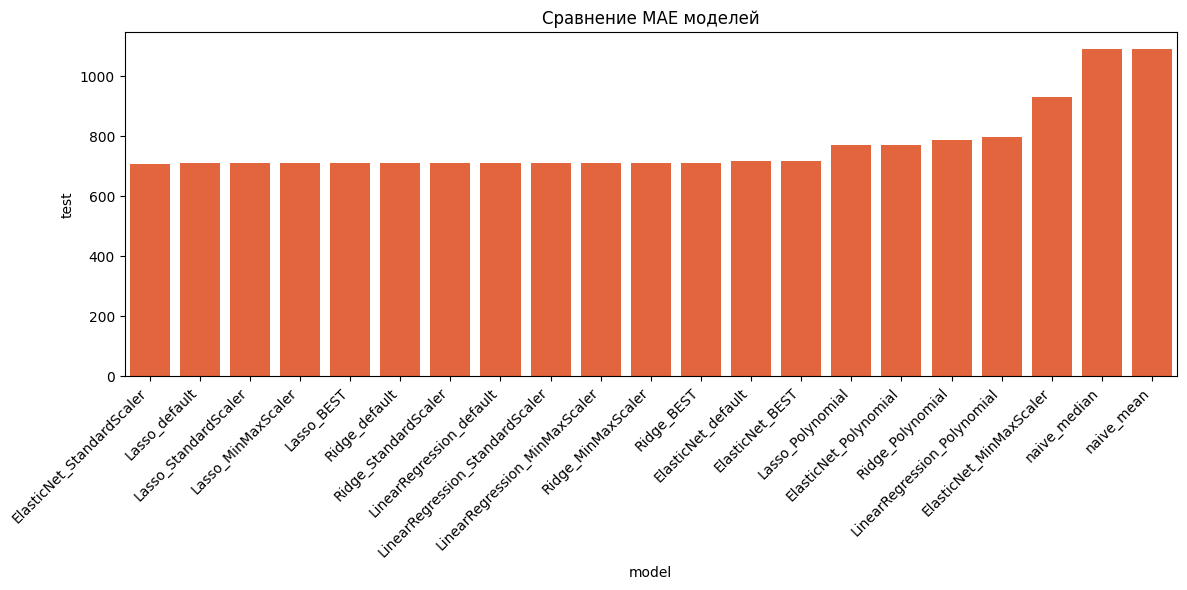

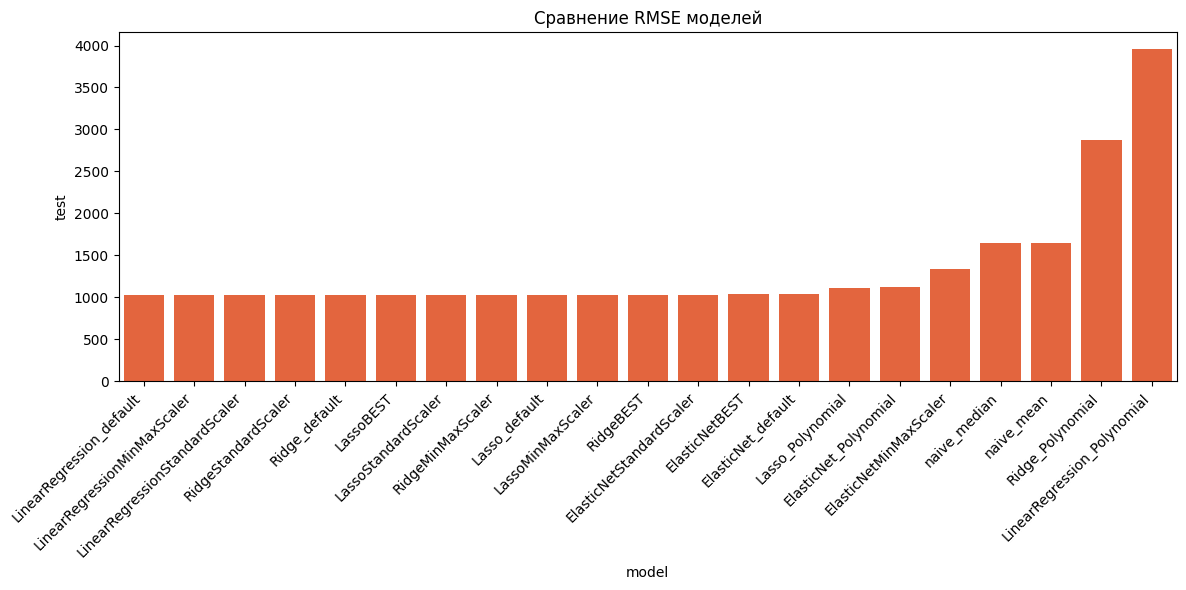

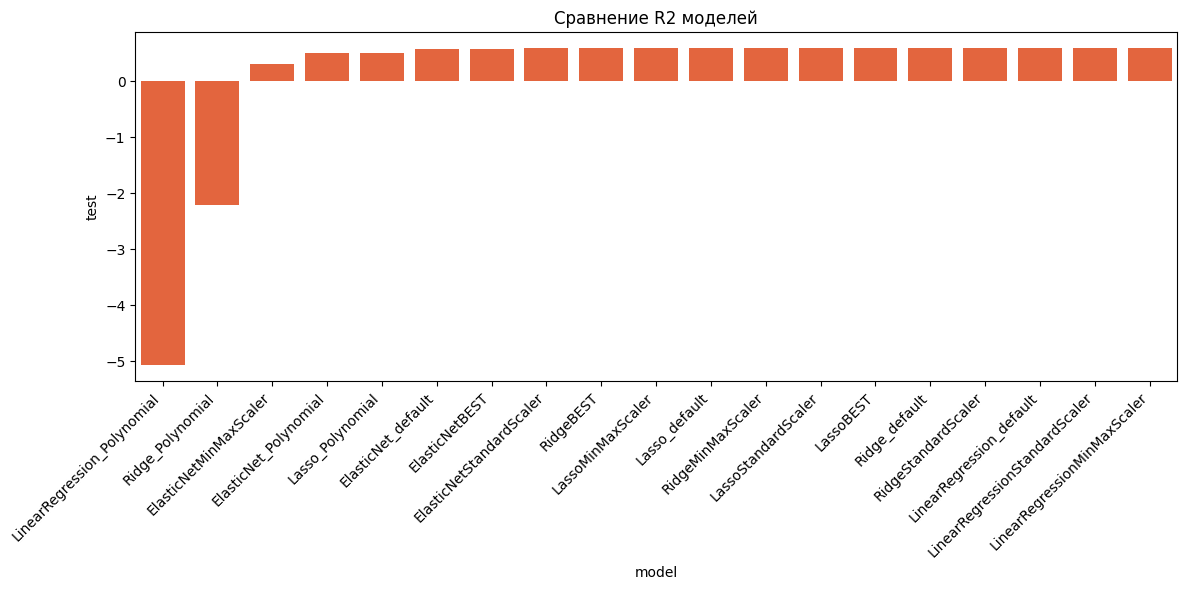

In [54]:
get_graph(tableMAE, 'MAE')
get_graph(tableRMSE, 'RMSE')
get_graph(tableR2, 'R2')

<div style="
    padding: 18px 0 12px 0;
    margin: 25px 0 20px 0;
    text-align: center;
    border-top: 1px solid rgba(208, 49, 30, 0.25);
    border-bottom: 1px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    border-radius: 4px;
">
    <span style="
        display: inline-block;
        font-size: 10px;
        color: #F7D87F;
        font-weight: 600;
        letter-spacing: 4px;
        text-transform: uppercase;
        margin-bottom: 4px;
    ">
        Chapter 11
    </span>
    <h2 style="
        margin: 0;
        color: #FF5722;
        font-size: 24px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        Addition task
    </h2>
</div>

<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※ 1
        </span>
        Логарифмирование признаков
    </h2>
</div>

In [55]:
def run_log_experiment(X_train, X_val, y_train, y_val, models):
    y_train_log = np.log1p(y_train)

    models = [
        ('LinearRegression', LinearRegression()),
        ('Ridge', Ridge(alpha=0.1)),
        ('Lasso', Lasso(alpha=0.1, random_state=21, max_iter=100)),
        ('ElasticNet', ElasticNet(alpha=0.1, random_state=21, max_iter=100, l1_ratio=0.5))
    ]
    
    tableMAE, tableRMSE, tableR2 = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    
    for name, model in models:
        model.fit(X_train, y_train_log)
        
        train_pred_log = model.predict(X_train)
        test_pred_log = model.predict(X_val)
        
        train_pred = np.expm1(train_pred_log)
        test_pred = np.expm1(test_pred_log)
        
        train_mae = mae(y_train, train_pred)
        test_mae = mae(y_val, test_pred)
        train_rmse = np.sqrt(mse(y_train, train_pred))
        test_rmse = np.sqrt(mse(y_val, test_pred))
        train_r2 = R2_score(y_train, train_pred)
        test_r2 = R2_score(y_val, test_pred)
        
        tableMAE = pd.concat([tableMAE, pd.DataFrame({
            'model': [f'{name}_log'],
            'train': [train_mae],
            'test': [test_mae],
            'variance': [train_mae - test_mae]
        })], ignore_index=True)
        
        tableRMSE = pd.concat([tableRMSE, pd.DataFrame({
            'model': [f'{name}_log'],
            'train': [train_rmse],
            'test': [test_rmse],
            'variance': [train_rmse - test_rmse]
        })], ignore_index=True)
        
        tableR2 = pd.concat([tableR2, pd.DataFrame({
            'model': [f'{name}_log'],
            'train': [train_r2],
            'test': [test_r2],
            'variance': [train_r2 - test_r2]
        })], ignore_index=True)
    
    return tableMAE, tableRMSE, tableR2

models = [
    LinearRegression(),
    Ridge(alpha=0.1),
    Lasso(alpha=0.1, random_state=21, max_iter=100),
    ElasticNet(alpha=0.1, random_state=21, max_iter=100, l1_ratio=0.5)
]

tableMAE_b, tableRMSE_b, tableR2_b = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()


tableMAE_log, tableRMSE_log, tableR2_log = run_log_experiment(
    X_train, X_val, y_train, y_val, feature_list
)
for i in models:
    tableMAE_b, tableRMSE_b, tableR2_b = processing_model(i, tableMAE_b, tableRMSE_b, tableR2_b, X_train, y_train, X_val, y_val, 'default')

tableMAE_all = pd.concat([tableMAE_b, tableMAE_log], ignore_index=True)
tableRMSE_all = pd.concat([tableRMSE_b, tableRMSE_log], ignore_index=True)
tableR2_all = pd.concat([tableR2_b, tableR2_log], ignore_index=True)

display_table(tableMAE_all.sort_values('model'), "MAE: сравнение", True)
display_table(tableRMSE_all.sort_values('model'), "RMSE: сравнение", True)
display_table(tableR2_all.sort_values('model'), "R2: сравнение", True)

model,train,test,variance
ElasticNet_default,713.577042,716.646119,-3.069078
ElasticNet_log,838.958441,845.426000,-6.467559
Lasso_default,708.358631,709.511813,-1.153182
Lasso_log,922.963431,932.282424,-9.318993
LinearRegression_default,708.419581,709.542370,-1.122789
LinearRegression_log,694.765265,698.109213,-3.343948
Ridge_default,708.419237,709.542231,-1.122993
Ridge_log,694.765436,698.109557,-3.344120


model,train,test,variance
ElasticNet_default,1042.020163,1042.612479,-0.592317
ElasticNet_log,1284.027638,1295.529327,-11.501689
Lasso_default,1028.238369,1023.945529,4.292840
Lasso_log,1408.330432,1426.152912,-17.822480
LinearRegression_default,1028.236443,1023.924425,4.312017
LinearRegression_log,1053.515830,1034.446793,19.069037
Ridge_default,1028.236443,1023.924757,4.311686
Ridge_log,1053.514892,1034.447517,19.067374


model,train,test,variance
ElasticNet_default,0.565305,0.578559,-0.013255
ElasticNet_log,0.339943,0.349294,-0.009351
Lasso_default,0.576727,0.593515,-0.016788
Lasso_log,0.205961,0.211462,-0.005501
LinearRegression_default,0.576729,0.593532,-0.016803
LinearRegression_log,0.555661,0.585135,-0.029474
Ridge_default,0.576729,0.593532,-0.016803
Ridge_log,0.555661,0.585134,-0.029473


<div style="
    padding: 12px 0 8px 0;
    margin: 30px 0 18px 0;
    border-bottom: 2px solid rgba(208, 49, 30, 0.25);
    background: rgba(208, 49, 30, 0.02);
    padding-left: 15px;
    border-radius: 3px;
">
    <h2 style="
        margin: 0;
        color: #F7D87F;
        font-size: 22px;
        font-weight: 600;
        letter-spacing: 0.5px;
    ">
        <span style="
            color: #FF5722;
            font-weight: 300;
            font-size: 18px;
            margin-right: 10px;
        ">
            ※ 2
        </span>
        Влияние выбросов на модель
    </h2>
</div>

In [56]:
train_data = pd.read_json('data/train.json')
test_data = pd.read_json('data/test.json')

train, test, feature_list = processing_data(train, test)

X_train, X_val, y_train, y_val = train_test_split(
    train[feature_list], 
    train['price'], 
    test_size=0.2,
    random_state=21
)

Всего значений train: 404920
Уникальных значений train: 2080
Всего значений test: 262377
Уникальных значений test: 1529


In [57]:
models = [
    LinearRegression(),
    Ridge(alpha=0.1),
    Lasso(alpha=0.1, random_state=21, max_iter=100),
    ElasticNet(alpha=0.1, random_state=21, max_iter=100, l1_ratio=0.5)
]

best = [
    Ridge(alpha=1.0),
    Lasso(alpha=0.01, random_state=21, max_iter=100),
    ElasticNet(alpha=0.001, random_state=21, max_iter=100, l1_ratio=0.5)
]

tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

poly = PolynomialFeatures(degree=10)
X_poly_train = poly.fit_transform(X_train[['bathrooms', 'bedrooms']])
X_poly_val = poly.transform(X_val[['bathrooms', 'bedrooms']])

for i in models:
    tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping = processing_model(i, tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping, X_train, y_train, X_val, y_val, 'default_unclipping')
for i in models:
    tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping = scaler_processing(i, tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping, X_train, y_train, X_val, y_val, "unclipping")
for i in models:
    tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping = scaler_processing(i, tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping, X_train, y_train, X_val, y_val, 'StandardScaler_unclipping')
for i in best:
    tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping = scaler_processing(i, tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping, X_train, y_train, X_val, y_val, 'BEST_unclipping')
for i in models:
    tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping = processing_model(i, tableMAE_unclipping, tableRMSE_unclipping, tableR2_unclipping, X_poly_train, y_train, X_poly_val, y_val, "Polynomial_unclipping")

dummy = DummyRegressor(strategy='median').fit(X_train, y_train)

train_pred = dummy.predict(X_train)
test_pred = dummy.predict(X_val)

tableMAE_unclipping = concatenate(tableMAE_unclipping, 'naive_median', 'mae', train_pred, test_pred, y_train, y_val)
tableRMSE_unclipping = concatenate(tableRMSE_unclipping, 'naive_median', 'rmse', train_pred, test_pred, y_train, y_val)

train_pred = dummy.predict(X_train)
test_pred = dummy.predict(X_val)

tableMAE_unclipping = concatenate(tableMAE_unclipping, 'naive_mean', 'mae', train_pred, test_pred, y_train, y_val)
tableRMSE_unclipping = concatenate(tableRMSE_unclipping, 'naive_mean', 'rmse', train_pred, test_pred, y_train, y_val)

/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.285e+10, tolerance: 9.660e+06
  model = cd_fast.enet_coordinate_descent(
/home/jarvis/pandasvenv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.314e+10, tolerance: 9.660e+06
  model = cd_fast.enet_coordinate_descent(


In [58]:
metrics = {
    'MAE': tableMAE_unclipping,
    'RMSE': tableRMSE_unclipping,
    'R2': tableR2_unclipping
}
for name, table in metrics.items():
    display_table(table.sort_values(by='test'), f"{name} моделей различной нормализации", True)

model,train,test,variance
Lasso_default_unclipping,708.358631,709.511813,-1.153182
Lasso_unclipping,708.380636,709.539542,-1.158906
Lasso_StandardScaler_unclipping,708.380636,709.539542,-1.158906
Lasso_BEST_unclipping,708.415381,709.541661,-1.126281
Ridge_default_unclipping,708.419237,709.542231,-1.122993
LinearRegression_StandardScaler_unclipping,708.419581,709.542370,-1.122789
LinearRegression_unclipping,708.419581,709.542370,-1.122789
LinearRegression_default_unclipping,708.419581,709.542370,-1.122789
Ridge_unclipping,708.430171,709.559783,-1.129612
Ridge_StandardScaler_unclipping,708.430171,709.559783,-1.129612


model,train,test,variance
LinearRegression_default_unclipping,1028.236443,1023.924425,4.312017
LinearRegressionunclipping,1028.236443,1023.924425,4.312017
LinearRegressionStandardScaler_unclipping,1028.236443,1023.924425,4.312017
Ridge_default_unclipping,1028.236443,1023.924757,4.311686
LassoBEST_unclipping,1028.236485,1023.929424,4.307061
RidgeStandardScaler_unclipping,1028.236956,1023.942958,4.293998
Ridgeunclipping,1028.236956,1023.942958,4.293998
Lasso_default_unclipping,1028.238369,1023.945529,4.292840
Lassounclipping,1028.240675,1023.978316,4.262359
LassoStandardScaler_unclipping,1028.240675,1023.978316,4.262359


model,train,test,variance
LinearRegression_Polynomial_unclipping,0.541387,-5.077281,5.618668
Ridge_Polynomial_unclipping,0.541210,-2.212593,2.753803
ElasticNetStandardScaler_unclipping,0.301014,0.308533,-0.007519
ElasticNetunclipping,0.301014,0.308533,-0.007519
ElasticNet_Polynomial_unclipping,0.526094,0.511163,0.014930
Lasso_Polynomial_unclipping,0.527145,0.516393,0.010752
ElasticNet_default_unclipping,0.565305,0.578559,-0.013255
ElasticNetBEST_unclipping,0.568164,0.582988,-0.014824
RidgeBEST_unclipping,0.576688,0.593351,-0.016663
Lassounclipping,0.576725,0.593489,-0.016764


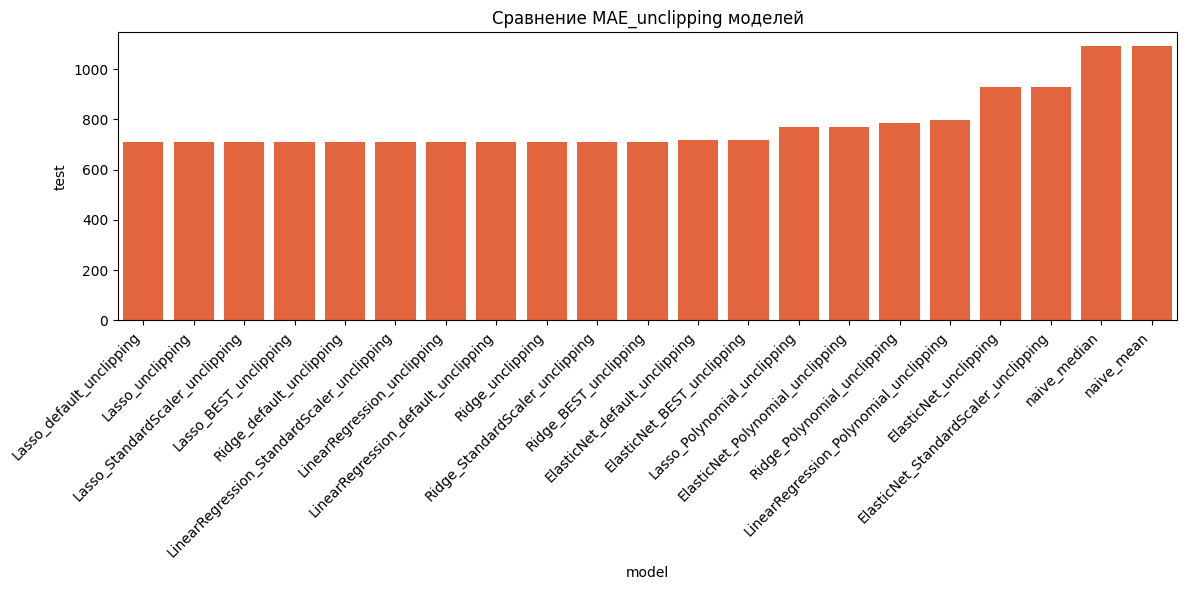

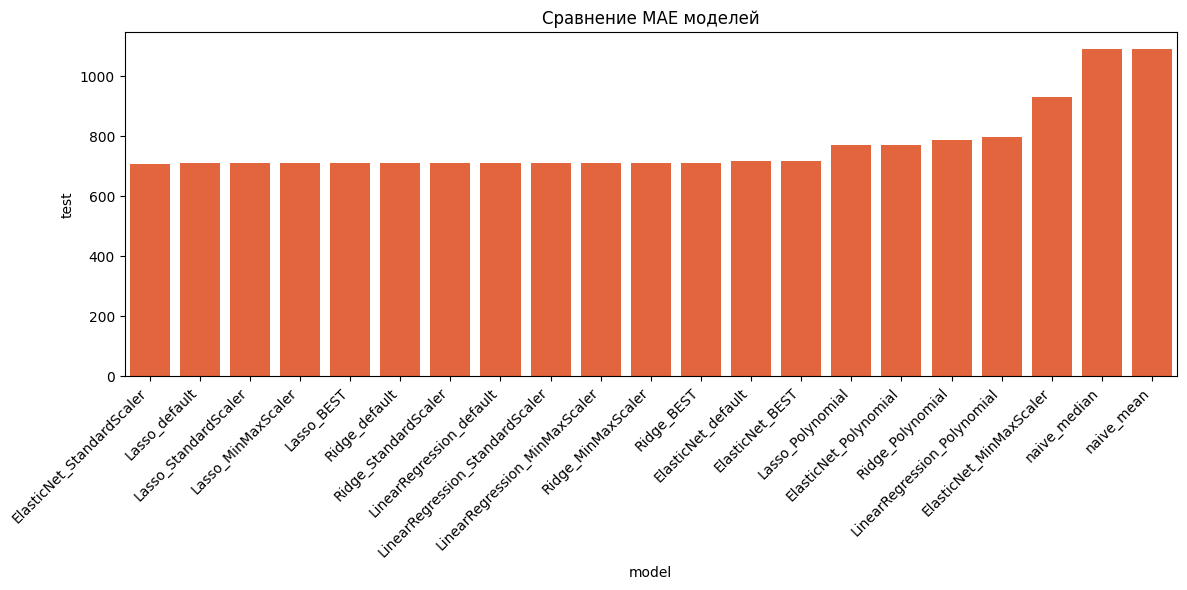

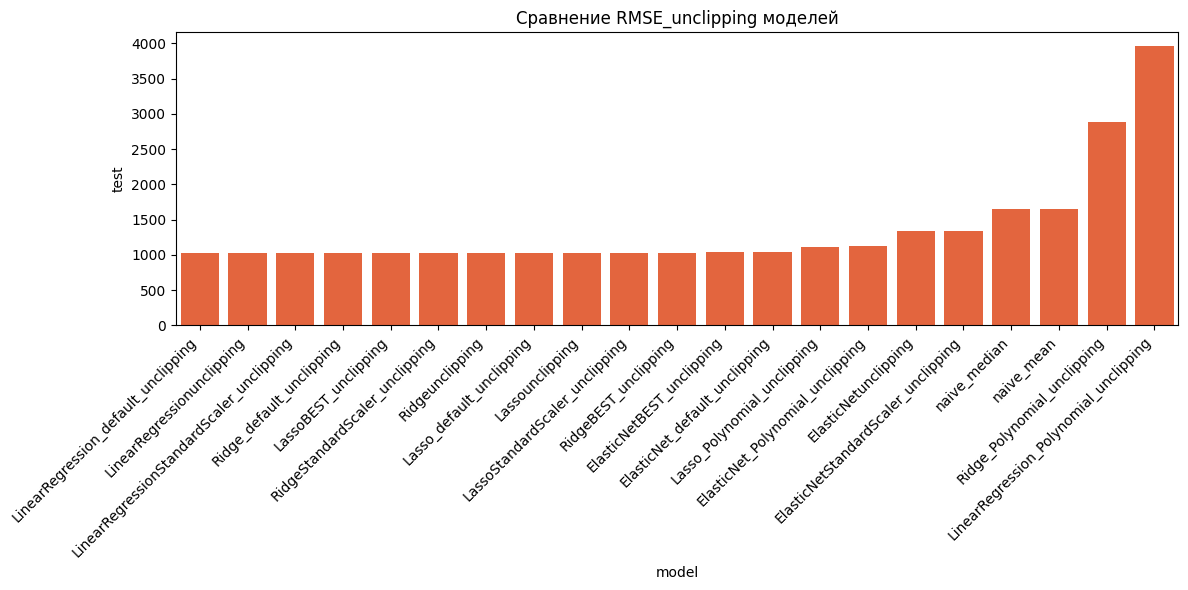

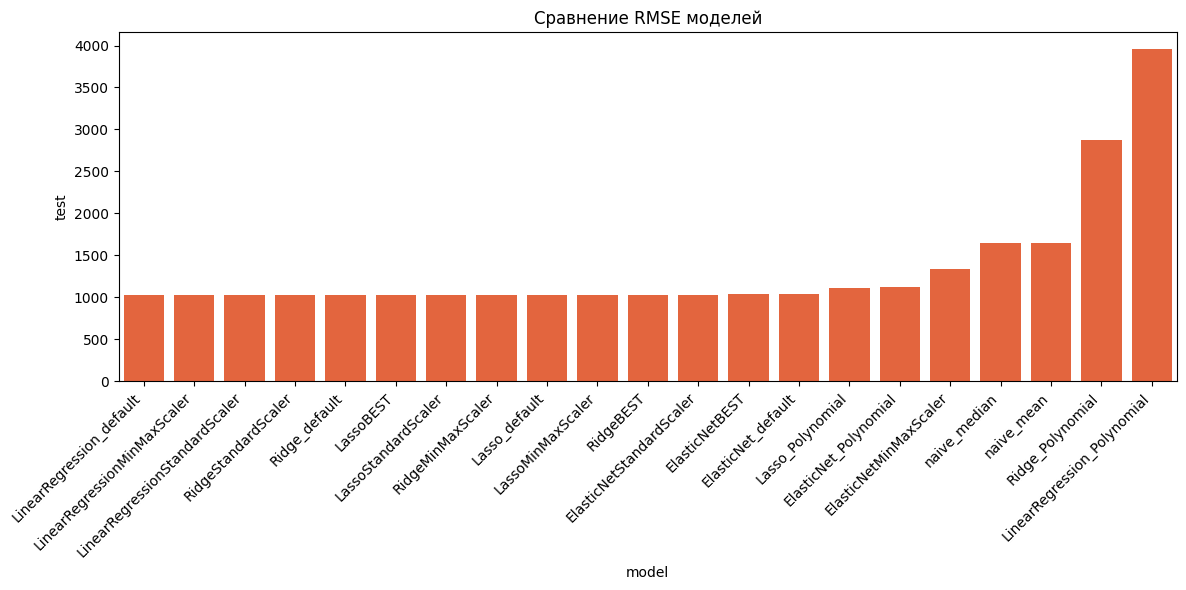

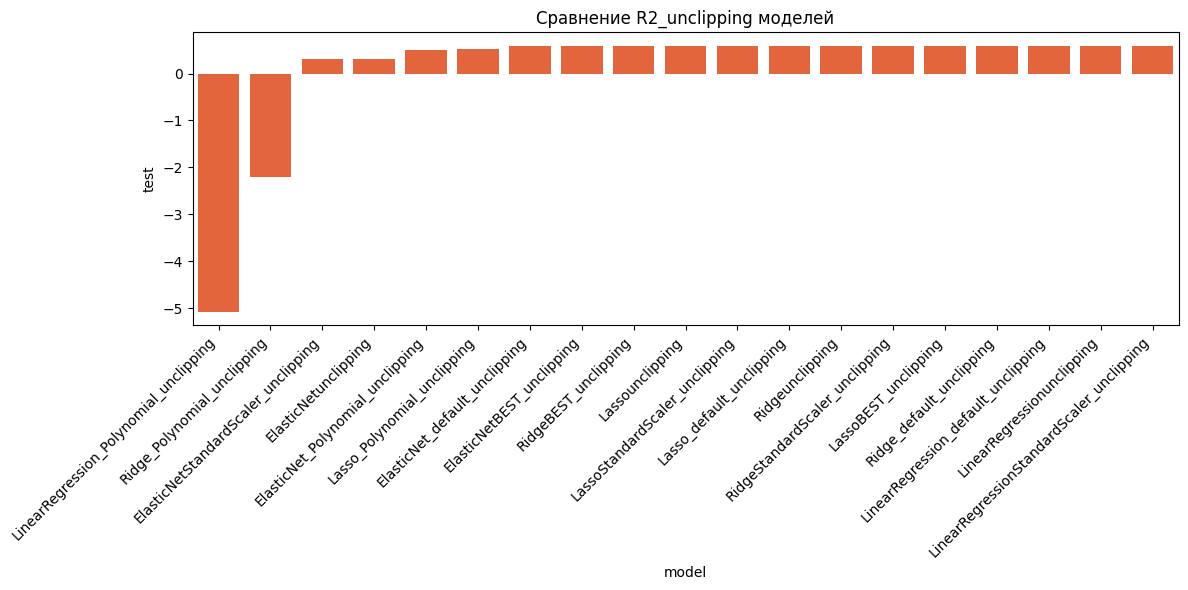

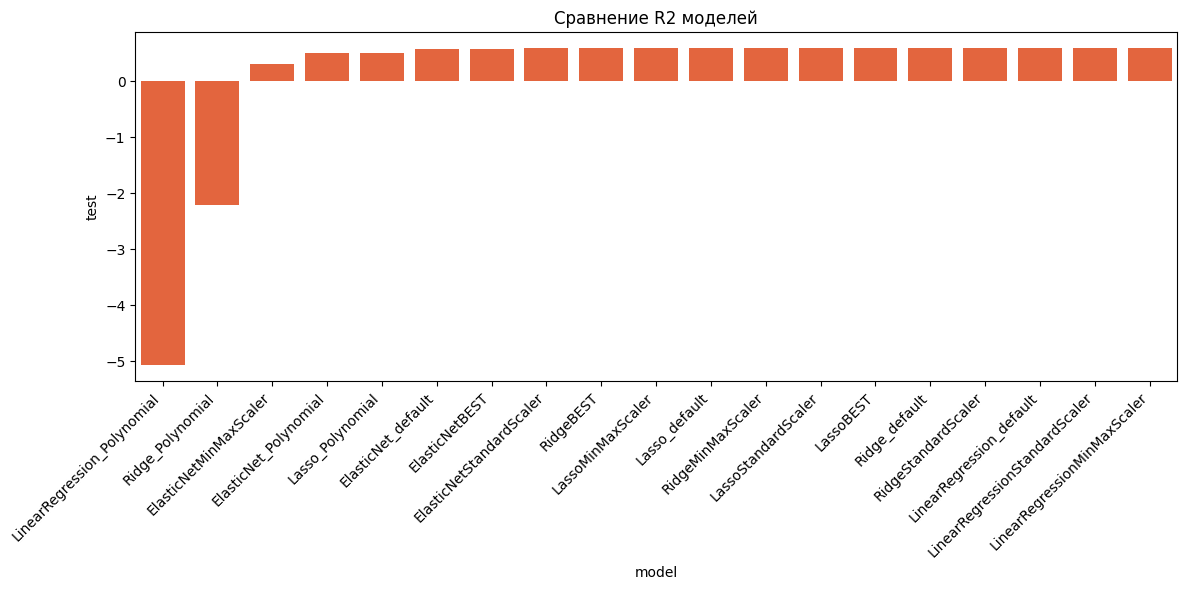

In [59]:
get_graph(tableMAE_unclipping, 'MAE_unclipping')
get_graph(tableMAE, 'MAE')
get_graph(tableRMSE_unclipping, 'RMSE_unclipping')
get_graph(tableRMSE, 'RMSE')
get_graph(tableR2_unclipping, 'R2_unclipping')
get_graph(tableR2, 'R2')